## 1. Imports

In [2]:
import os
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## 2. Download the Jena Climate dataset

This grabs the standard `jena_climate_2009_2016.csv` file (the same one used in the Keras/TF time-series tutorial) and caches it locally so re-running the notebook doesn't re-download it.


In [3]:
DATA_DIR = "data"
ZIP_PATH = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv.zip")
CSV_PATH = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")
URL = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    if not os.path.exists(ZIP_PATH):
        print("Downloading Jena Climate dataset...")
        r = requests.get(URL, timeout=60)
        r.raise_for_status()
        with open(ZIP_PATH, "wb") as f:
            f.write(r.content)
    print("Extracting...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already present, skipping download.")


Dataset already present, skipping download.


In [4]:
df_raw = pd.read_csv(CSV_PATH)
df_raw.head()


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3. Parse timestamps and resample 10-min data to hourly

The raw data is sampled every 10 minutes (144 rows/day). We convert `Date Time` to a proper datetime index, then resample to hourly resolution by **averaging every 6 consecutive rows** (10 min x 6 = 60 min).


In [5]:
df_raw["Date Time"] = pd.to_datetime(df_raw["Date Time"], format="%d.%m.%Y %H:%M:%S")
df_raw = df_raw.set_index("Date Time").sort_index()

# sanity check: should be 10-minute spacing
print(df_raw.index.to_series().diff().value_counts().head())
df_raw.shape

Date Time
0 days 00:10:00    420218
0 days 00:00:00       327
0 days 00:20:00         2
0 days 00:30:00         1
0 days 16:00:00         1
Name: count, dtype: int64


(420551, 14)

In [22]:
df_hourly = df_raw.resample("1h").mean()
df_hourly = df_hourly.dropna()  # drop any incomplete hour at the edges

print(df_hourly.shape)
df_hourly.head()

(70041, 14)


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


## 4. Feature / target selection and train-val-test split

We use all weather variables as input features and forecast the temperature column T (degC).

In [7]:
feature_cols = list(df_hourly.columns)
target_col = "T (degC)"
target_idx = feature_cols.index(target_col)

print(f"Number of features: {len(feature_cols)}")
print(f"Target column: {target_col} (index {target_idx})")

data = df_hourly[feature_cols].values.astype(np.float32)

n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(f"Train: {train_data.shape}, Val: {val_data.shape}, Test: {test_data.shape}")

Number of features: 14
Target column: T (degC) (index 1)
Train: (49028, 14), Val: (10506, 14), Test: (10507, 14)


In [8]:
# normalizig the datasets based on train stats to avoid leakage
mean = train_data.mean(axis=0, keepdims=True)
std = train_data.std(axis=0, keepdims=True) + 1e-8

def normalize(x):
    return (x - mean) / std

train_norm = normalize(train_data)
val_norm = normalize(val_data)
test_norm = normalize(test_data)

# keep the mean/std of the target column so we can un-normalize predictions later
target_mean = mean[0, target_idx]
target_std = std[0, target_idx]
print(f"Target mean: {target_mean:.3f}, std: {target_std:.3f}")

Target mean: 9.099, std: 8.645


## 5. 72h input -> next 12h output (temperature)

In [9]:
INPUT_HOURS = 72
OUTPUT_HOURS = 12

def make_windows(arr, target_idx, input_len=INPUT_HOURS, output_len=OUTPUT_HOURS):
    X, y = [], []
    n_samples = len(arr) - input_len - output_len + 1
    for i in range(n_samples):
        X.append(arr[i : i + input_len])
        y.append(arr[i + input_len : i + input_len + output_len, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = make_windows(train_norm, target_idx)
X_val, y_val = make_windows(val_norm, target_idx)
X_test, y_test = make_windows(test_norm, target_idx)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train: (48945, 72, 14), y_train: (48945, 12)
X_val:   (10423, 72, 14), y_val:   (10423, 12)
X_test:  (10424, 72, 14), y_test:  (10424, 12)


In [10]:
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128

train_ds = WeatherDataset(X_train, y_train)
val_ds = WeatherDataset(X_val, y_val)
test_ds = WeatherDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)

(48945, 10423, 10424)

## 6. Custom LSTM cell

In [11]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size

        # forget gate
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)

        # input gate
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)

        # candidate cell state
        self.W_c = nn.Linear(input_size + hidden_size, hidden_size)

        # output gate
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev, c_prev):
        combined = torch.cat((h_prev, x), dim=1)

        # forget gate
        f_t = torch.sigmoid(self.W_f(combined))

        # input gate
        i_t = torch.sigmoid(self.W_i(combined))

        # candidate cell state
        c_cap = torch.tanh(self.W_c(combined))

        # cell state update
        c_t = (c_prev * f_t) + (c_cap * i_t)

        # output gate
        o_t = torch.sigmoid(self.W_o(combined))

        # hidden state update
        h_t = o_t * torch.tanh(c_t)

        return h_t, c_t

## 7. Single-layer LSTM wrapper

Runs the LSTMCell over a sequence, returning outputs for every timestep plus the final (h, c).


In [12]:
class LSTMLayer(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = LSTMCell(input_size, hidden_size)

    def forward(self, x, h_t=None, c_t=None):
        batch_size = x.size(0)
        seq_len = x.size(1)

        if h_t is None:
            h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        if c_t is None:
            c_t = torch.zeros(batch_size, self.hidden_size, device=x.device)

        outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :]
            h_t, c_t = self.cell(x_t, h_t, c_t)
            outputs.append(h_t.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)
        return outputs, (h_t, c_t)

## 8. Stacked LSTM (up to 2 layers) with dropout between layers

Layer 2 (if used) consumes the hidden-state sequence produced by layer 1.

In [13]:
class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.2):
        super().__init__()
        assert 1 <= num_layers <= 2
        assert 32 <= hidden_size <= 256

        self.num_layers = num_layers
        self.hidden_size = hidden_size

        self.layers = nn.ModuleList()
        for layer_idx in range(num_layers):
            in_size = input_size if layer_idx == 0 else hidden_size
            self.layers.append(LSTMLayer(in_size, hidden_size))

        self.dropout = nn.Dropout(dropout) if num_layers > 1 else nn.Identity()

    def forward(self, x):
        out = x
        final_h, final_c = None, None
        for i, layer in enumerate(self.layers):
            out, (final_h, final_c) = layer(out)
            if i < self.num_layers - 1:
                out = self.dropout(out)
        return out, (final_h, final_c)

## 9. Forecasting model

`StackedLSTM` encodes the 72-hour input window; the **final hidden state** is passed through a small MLP head that outputs the 12 future hourly temperatures directly (a multi-step "direct" forecast, avoiding autoregressive error accumulation).


In [14]:
class WeatherForecastLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, output_steps=OUTPUT_HOURS, dropout=0.2):
        super().__init__()
        self.lstm = StackedLSTM(input_size, hidden_size, num_layers=num_layers, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, output_steps),
        )

    def forward(self, x):
        _, (h_final, _) = self.lstm(x)
        return self.head(h_final)

## 10. Hyperparameters and training setup

In [15]:
INPUT_SIZE = len(feature_cols)
HIDDEN_SIZE = 64        # in [32, 256]
NUM_LAYERS = 2          # <= 2
DROPOUT = 0.2
LR = 1e-3
EPOCHS = 20
PATIENCE = 4            # early stopping patience

model = WeatherForecastLSTM(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_steps=OUTPUT_HOURS,
    dropout=DROPOUT,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

WeatherForecastLSTM(
  (lstm): StackedLSTM(
    (layers): ModuleList(
      (0): LSTMLayer(
        (cell): LSTMCell(
          (W_f): Linear(in_features=78, out_features=64, bias=True)
          (W_i): Linear(in_features=78, out_features=64, bias=True)
          (W_c): Linear(in_features=78, out_features=64, bias=True)
          (W_o): Linear(in_features=78, out_features=64, bias=True)
        )
      )
      (1): LSTMLayer(
        (cell): LSTMCell(
          (W_f): Linear(in_features=128, out_features=64, bias=True)
          (W_i): Linear(in_features=128, out_features=64, bias=True)
          (W_c): Linear(in_features=128, out_features=64, bias=True)
          (W_o): Linear(in_features=128, out_features=64, bias=True)
        )
      )
    )
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=12, bias=True

## 11. Training loop (with early stopping)

In [16]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = 0.0
    n_batches = 0

    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            if train:
                optimizer.zero_grad()

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1

    return total_loss / n_batches

In [17]:
train_losses, val_losses = [], []
best_val_loss = float("inf")
best_state = None
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, train=True)
    val_loss = run_epoch(val_loader, train=False)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch:2d}/{EPOCHS} | train MSE: {train_loss:.4f} | val MSE: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best model with val MSE: {best_val_loss:.4f}")


Epoch  1/20 | train MSE: 0.1969 | val MSE: 0.0736
Epoch  2/20 | train MSE: 0.0802 | val MSE: 0.0632
Epoch  3/20 | train MSE: 0.0722 | val MSE: 0.0589
Epoch  4/20 | train MSE: 0.0683 | val MSE: 0.0566
Epoch  5/20 | train MSE: 0.0662 | val MSE: 0.0552
Epoch  6/20 | train MSE: 0.0643 | val MSE: 0.0554
Epoch  7/20 | train MSE: 0.0635 | val MSE: 0.0541
Epoch  8/20 | train MSE: 0.0613 | val MSE: 0.0563
Epoch  9/20 | train MSE: 0.0613 | val MSE: 0.0516
Epoch 10/20 | train MSE: 0.0594 | val MSE: 0.0518
Epoch 11/20 | train MSE: 0.0585 | val MSE: 0.0539
Epoch 12/20 | train MSE: 0.0575 | val MSE: 0.0518
Epoch 13/20 | train MSE: 0.0549 | val MSE: 0.0519
Early stopping at epoch 13 (no val improvement for 4 epochs).

Loaded best model with val MSE: 0.0516


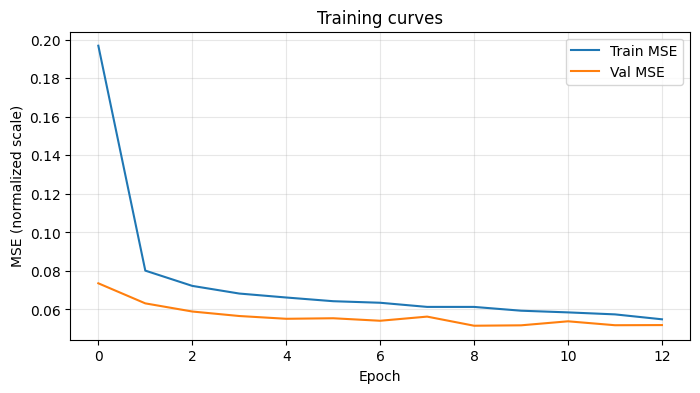

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train MSE")
plt.plot(val_losses, label="Val MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE (normalized scale)")
plt.title("Training curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 12. Evaluation on the test set

Metrics are reported in **degrees Celsius** (un-normalized) since MSE in normalized-feature units isn't very interpretable on its own.


Test MAE:  1.387 degC
Test RMSE: 1.883 degC


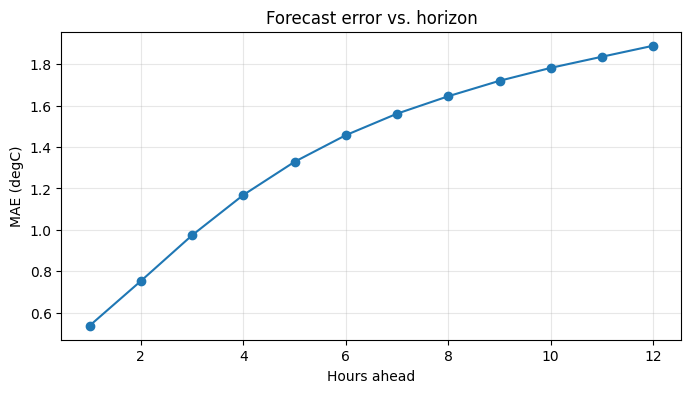

In [19]:
def unnormalize_target(y):
    return y * target_std + target_mean

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        all_preds.append(preds)
        all_targets.append(y_batch.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

preds_c = unnormalize_target(all_preds)
targets_c = unnormalize_target(all_targets)

mae = np.mean(np.abs(preds_c - targets_c))
rmse = np.sqrt(np.mean((preds_c - targets_c) ** 2))

print(f"Test MAE:  {mae:.3f} degC")
print(f"Test RMSE: {rmse:.3f} degC")

# error per forecast horizon (hour 1..12 ahead)
mae_per_step = np.mean(np.abs(preds_c - targets_c), axis=0)
plt.figure(figsize=(8, 4))
plt.plot(range(1, OUTPUT_HOURS + 1), mae_per_step, marker="o")
plt.xlabel("Hours ahead")
plt.ylabel("MAE (degC)")
plt.title("Forecast error vs. horizon")
plt.grid(alpha=0.3)
plt.show()


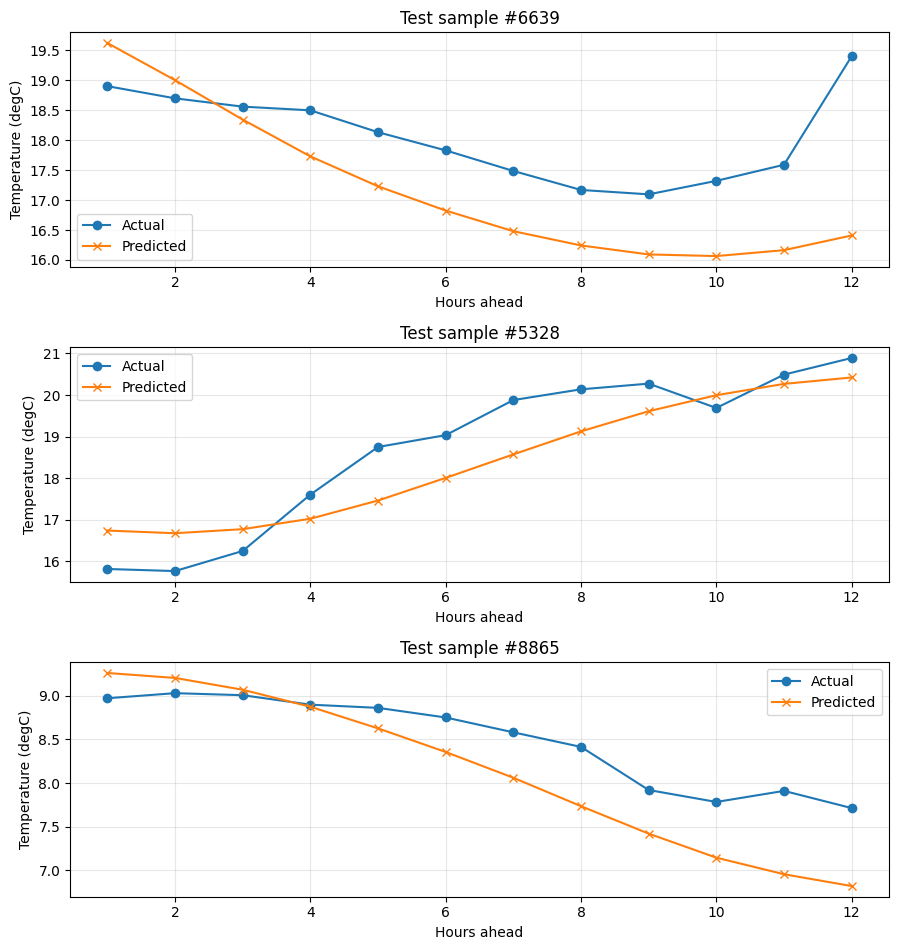

In [20]:
# Visualize a handful of individual forecasts vs. ground truth
n_examples = 3
fig, axes = plt.subplots(n_examples, 1, figsize=(9, 3.2 * n_examples))

rng = np.random.default_rng(0)
sample_idxs = rng.choice(len(preds_c), size=n_examples, replace=False)

for ax, idx in zip(axes, sample_idxs):
    ax.plot(range(1, OUTPUT_HOURS + 1), targets_c[idx], label="Actual", marker="o")
    ax.plot(range(1, OUTPUT_HOURS + 1), preds_c[idx], label="Predicted", marker="x")
    ax.set_title(f"Test sample #{idx}")
    ax.set_xlabel("Hours ahead")
    ax.set_ylabel("Temperature (degC)")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 13. Save the trained model

Saves weights plus normalization stats, so the model can be reloaded for inference without recomputing statistics from the training set.


In [21]:
os.makedirs("checkpoints", exist_ok=True)
torch.save({
    "model_state_dict": model.state_dict(),
    "feature_cols": feature_cols,
    "target_col": target_col,
    "mean": mean,
    "std": std,
    "input_hours": INPUT_HOURS,
    "output_hours": OUTPUT_HOURS,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
}, "checkpoints/weather_lstm.pt")

print("Saved model to checkpoints/weather_lstm.pt")

Saved model to checkpoints/weather_lstm.pt
